In [9]:
import numpy as np
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import seaborn as sns
from derive_velocity_attenuation_ratios_from_PIVlab_data import *
#from debugging_velatt import *

In [2]:
#Testing zone: unload files and variables

px_file_raw = "Input/Velocity Attenuation/uncalib_catiedata_score3_75pctspeed_unfiltered/catiethesisdata_score3_75pc_unfiltered_0100.txt"
px_root_raw = "Input/Velocity Attenuation/uncalib_catiedata_score3_75pctspeed_unfiltered/catiethesisdata_score3_75pc_unfiltered_"

px_file_filt = "Input/Velocity Attenuation/uncalib_catiedata_score3_75pctspeed_filtered/catiedata_score3_75pctspeed_filtered_0100.txt"
px_root_filt = "Input/Velocity Attenuation/uncalib_catiedata_score3_75pctspeed_filtered/catiedata_score3_75pctspeed_filtered_"

px_file_filt_nointerpolation = "Input/Velocity Attenuation/uncalib_catiedata_score3_75pctspeed_filtered_no-interpolation/catiedata_score3_75pct_filtered_nointerpolation_0100.txt"
px_root_filt_nointerpolation = "Input/Velocity Attenuation/uncalib_catiedata_score3_75pctspeed_filtered_no-interpolation/catiedata_score3_75pct_filtered_nointerpolation_"

calib_file_raw = "Input/Velocity Attenuation/calib_catiedata_score3_75pctspeed_unfiltered/calib_catiedata_score3_75pctspeed_unfiltered_0100.txt"
calib_root_raw = "Input/Velocity Attenuation/calib_catiedata_score3_75pctspeed_unfiltered/calib_catiedata_score3_75pctspeed_unfiltered_"

calib_file_filt = "Input/Velocity Attenuation/calib_catiedata_score3_75pctspeed_filtered/calib_catiedata_score3_75pctspeed_filtered_0100.txt"
calib_root_filt = "Input/Velocity Attenuation/calib_catiedata_score3_75pctspeed_filtered/calib_catiedata_score3_75pctspeed_filtered_"

In [3]:
radius = 40
data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange1, ymin, ymax, yrange1, pointarray_mag = break_down_data(px_file_filt)
unc_left = xrange1[18]
unc_right = xrange1[39]
unc_bott = yrange1[0]
unc_top = yrange1[7]
print(xrange1[18])
print(xrange1[39])
print(yrange1[0])
print(yrange1[7])
data, xcol, ycol, ucol, vcol, col_len, vec_dist, xmin, xmax, xrange2, ymin, ymax, yrange2, pointarray_mag = break_down_data(calib_file_filt)
c_left = xrange2[18]
c_right = xrange2[39]
c_bott = yrange2[0]
c_top = yrange2[7]
print(xrange2[18])
print(xrange2[39])
print(yrange2[0])
print(yrange2[7])

#uncalibrated: unc_left, unc_right, unc_bott, unc_top
#calibrated: c_left, c_right, c_bott, c_top

print(np.where(xrange1 == 801)[0])
print(np.where(yrange1 == 63)[0])

621
1041
23
163
0.02727967687
0.04572969675
0.001010358334
0.007160366047
[27]
[2]


In [4]:
about()

A set of functions meant to calculate velocity attenuation from processed PIVlab data.

    Overview of the functions in this file~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    For data analysis by the user:~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    velocity_attenuation_heatmap(String filename, float left, float right, float bott, float top)--- Returns a heatmap of the velocity attenuation 
    ratio for *one* frame of PIVlab data, as well as a list of the attenuation values for each pixel in the same order as the input data. Must define
    the free stream region.

    timeavg_velocity_attenuation_heatmap(String filename, int start_frame, int end_frame, float left, float right, float bott, float top, 
    int digits = 4)--- Returns a time-averaged heatmap of the velocity attenuation ratio from PIVlab data, as well as a 1D Numpy array of the 
    time-averaged attenuation values for each pixel in the same order as the input

In [5]:
#Sanity test 1: Calibrated vs uncalibrated for small area
#Test for Catie's 75pct filtered data...
#calibrated filtered = uncalibrated filtered (1 frame)
print("Rectangle:")
c_filt_1_rect = small_area_attenuation_rect(calib_file_filt, xrange2[7], xrange2[12], yrange2[6], yrange2[10], c_left, c_right, c_bott, c_top)
unc_filt_1_rect = small_area_attenuation_rect(px_file_filt, xrange1[7], xrange1[12], yrange1[6], yrange1[10], unc_left, unc_right, unc_bott, unc_top)
print(c_filt_1_rect , unc_filt_1_rect)

print("\nRadial:")
c_filt_1_rad = small_area_attenuation_rad(calib_file_filt, xrange2[9], yrange2[8], c_left, c_right, c_bott, c_top, 3)
unc_filt_1_rad = small_area_attenuation_rad(px_file_filt, xrange1[9], yrange1[8], unc_left, unc_right, unc_bott, unc_top, 3)
print(c_filt_1_rad , unc_filt_1_rad)

#calibrated filtered = uncalibrated filtered (10 frames)
print("\nRectangle Over Time:")
c_filt_10_rect = timeavg_small_area_attenuation_rect(calib_root_filt, 100, 110, xrange2[7], xrange2[12], yrange2[6], yrange2[10], c_left, c_right, c_bott, c_top)
unc_filt_10_rect = timeavg_small_area_attenuation_rect(px_root_filt, 100, 110, xrange1[7], xrange1[12], yrange1[6], yrange1[10], unc_left, unc_right, unc_bott, unc_top)
print(c_filt_10_rect , unc_filt_10_rect)

print("\nRadial Over Time:")
c_filt_10_rad = timeavg_small_area_attenuation_rad(calib_root_filt, 100, 110, xrange2[9], yrange2[8], c_left, c_right, c_bott, c_top, 3)
unc_filt_10_rad = timeavg_small_area_attenuation_rad(px_root_filt, 100, 110, xrange1[9], yrange1[8], unc_left, unc_right, unc_bott, unc_top, 3)
print(c_filt_10_rad , unc_filt_10_rad)

#
#Repeat for both rectangular and radial
#
#Free stream region bounds:
#Uncalibrated: left = 621 (xrange1[18]), right = 1041 (xrange1[39]), bottom = 23 (yrange1[0]), top = 163 (yrange1[7])
#Calibrated: left = 0.02727967687 (xrange2[18]), right = 0.04572969675 (xrange2[39]), bottom = 0.001010358334 (yrange2[0]), top = 0.007160366047 (yrange2[7])
#
#Rectangular ROI:
#Uncalibrated: left = 401 (xrange1[7]), right = 501 (xrange1[12]), bottom = 143 (yrange1[6]), top = 223 (yrange1[10])
#Calibrated: left =  0.006281793118 (xrange2[7]), right = 0.02200824022 (xrange2[12]), bottom = 0.006281793118 (yrange2[6]), top = 0.009796082973 (yrange2[10])
#
#Radial ROI:
#Uncalibrated: x = 441 (xrange1[9]), y = 183 (yrange1[8]), radius = (~3 vectors from center)
#Calibrated: x = 0.01937252283 (xrange2[9]), y = 0.008038938046 (yrange2[8]), radius = (~3 vectors from center)

Rectangle:
0.7649048252648634 0.7649048318644603

Radial:
0.7079035154764549 0.7079035201528198

Rectangle Over Time:
0.664490613326558 0.6644906139060247

Radial Over Time:
0.6756125001369454 0.6756125014780572


In [6]:
#Sanity test 2: Accuracy of small area functions
#Since I now have confirmation that uncalib = calib, I will use uncalibrated data since it's less decimal-y to parse
#Test for Catie's 75pct filtered, uncalibrated data...
#free stream region consistent with manual calculations for uncalibrated data
#attenuation ratio consistent for rectangular function (1 frame)
print("Rectangle:")
unc_filt_1_rect = small_area_attenuation_rect(px_file_filt, xrange1[7], xrange1[12], yrange1[7], yrange1[10], xrange1[20], xrange1[27], yrange1[0], yrange1[1])
print(unc_filt_1_rect)
#attenuation ratio consistent for radial function (1 frame)
print("\nRadial:")
unc_filt_1_rad = small_area_attenuation_rad(px_file_filt, xrange1[9], yrange1[8], xrange1[20], xrange1[27], yrange1[0], yrange1[1], 2)
print(unc_filt_1_rad)
#attenuation ratio consistent for rectangular function (2 frames)
print("\nRectangle Over Time:")
unc_filt_2_rect = timeavg_small_area_attenuation_rect(px_root_filt, 100, 101, xrange1[7], xrange1[12], yrange1[7], yrange1[10], xrange1[20], xrange1[27], yrange1[0], yrange1[1])
print(unc_filt_2_rect)
#attenuation ratio consistent for radial function (2 frames)
print("\nRadial Over Time:")
unc_filt_2_rad = timeavg_small_area_attenuation_rad(px_root_filt, 100, 101, xrange1[9], yrange1[8], xrange1[20], xrange1[27], yrange1[0], yrange1[1], 2)
print(unc_filt_2_rad)
#
#Free stream region bounds:
#Uncalibrated: left = 661 (xrange1[20]), right = 801 (xrange1[27]), bottom = 23 (yrange1[0]), top = 43 (yrange[1])
#
#Rectangular ROI:
#Uncalibrated: left = 401 (xrange1[7]), right = 501 (xrange1[12]), bottom = 163 (yrange1[7]), top = 223 (yrange1[10])
#
#Radial ROI:
#Uncalibrated: x = 441 (xrange1[9]), y = 183 (yrange1[8]), radius = (~2 vectors from center, 8 vectors encapsulated)

Rectangle:
0.5980502808252587

Radial:
0.5689607488658043

Rectangle Over Time:
0.5017019595325429

Radial Over Time:
0.4953944719449048


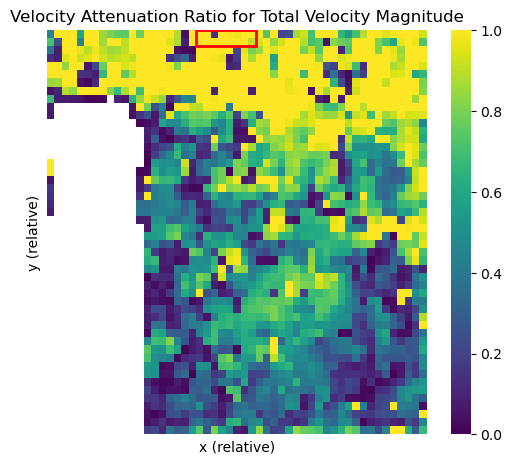

0.4475952208131367
0.7178903174367547
0.38989261194676256


In [7]:
#Sanity test 3: Accuracy of heatmaps
#Test for Catie's 75pct filtered data...
#free stream region consistent with manual calculations for uncalibrated data (1 frame)
uncalib_heat = velocity_attenuation_heatmap(px_file_filt, xrange1[20], xrange1[27], yrange1[0], yrange1[1])
print(uncalib_heat[0])
print(uncalib_heat[1])
print(uncalib_heat[2])
#A handful of indices manually calculated from txt data consistent for uncalibrated data
#
#Free stream region bounds:
#Uncalibrated: left = 661 (xrange1[20]), right = 801 (xrange1[27]), bottom = 23 (yrange1[0]), top = 43 (yrange[1])

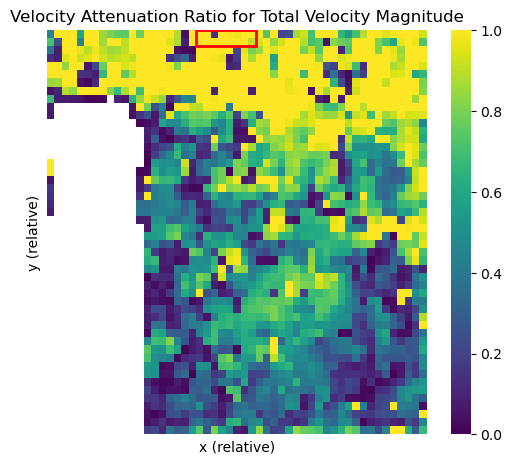

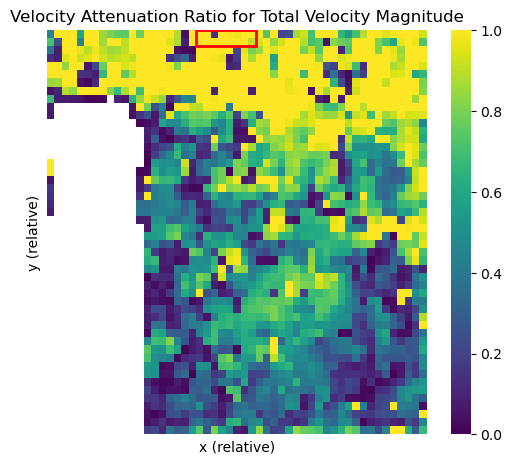

[0.44759521 0.7178903  0.3898926  ... 1.96803336 0.46792234 0.66810794]
[0.44759522 0.71789032 0.38989261 ... 1.96803333 0.46792234 0.66810797]


C:\Users\oksan\AppData\Roaming\.anaconda\navigator\scripts\SSR_2026\derive_velocity_attenuation_ratios_from_PIVlab_data.py:362: RuntimeWarning: invalid value encountered in divide
  mag_avg = mag_avg/val_pts #averaged over time


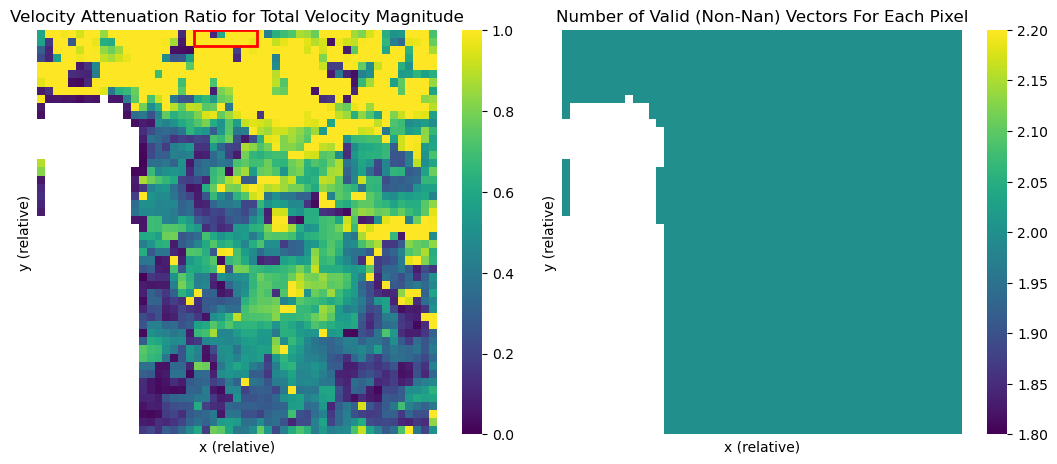

C:\Users\oksan\AppData\Roaming\.anaconda\navigator\scripts\SSR_2026\derive_velocity_attenuation_ratios_from_PIVlab_data.py:362: RuntimeWarning: invalid value encountered in divide
  mag_avg = mag_avg/val_pts #averaged over time


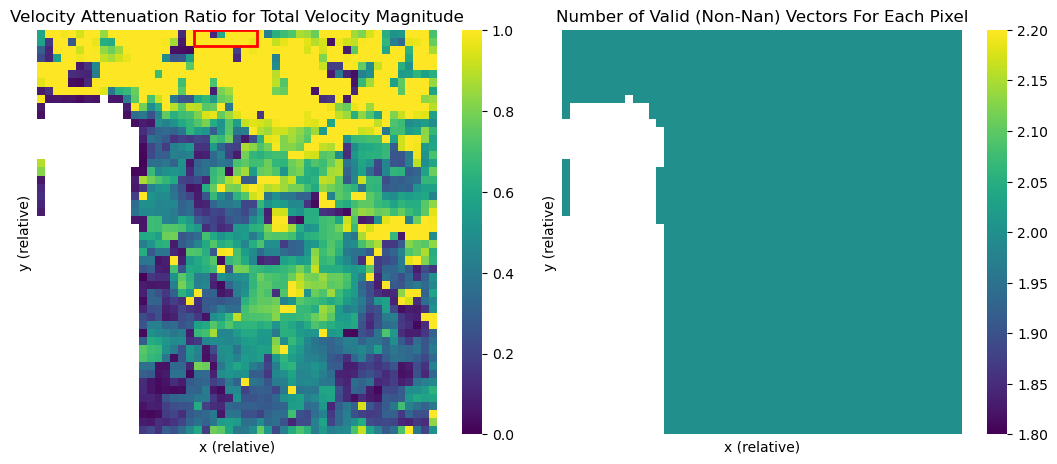

[0.59002998 0.57794774 0.29794887 ... 1.63848983 0.82981861 0.50533306]
[0.59003    0.57794775 0.29794888 ... 1.63848983 0.82981864 0.50533308]


In [8]:
#Sanity test 4: Calibrated vs uncalibrated heatmaps
calib_heat = velocity_attenuation_heatmap(calib_file_filt, xrange2[20], xrange2[27], yrange2[0], yrange2[1])
uncalib_heat = velocity_attenuation_heatmap(px_file_filt, xrange1[20], xrange1[27], yrange1[0], yrange1[1])
print(calib_heat)
print(uncalib_heat)

calib_heat = timeavg_velocity_attenuation_heatmap(calib_root_filt, 100, 101, xrange2[20], xrange2[27], yrange2[0], yrange2[1])
uncalib_heat = timeavg_velocity_attenuation_heatmap(px_root_filt, 100, 101, xrange1[20], xrange1[27], yrange1[0], yrange1[1])
print(calib_heat)
print(uncalib_heat)